# Comparative Analysis of Machine Learning Algorithms for Rice Yield Prediction\n
\n
This notebook compares multiple machine learning algorithms on the `jalpaiguri_rice_detailed.csv` dataset. \n
We will evaluate their performance in predicting **Rice Yield (t/ha)**.\n
\n
**Algorithms Included:**\n
1.  **Random Forest Regressor** (Ensemble)\n
2.  **K-Nearest Neighbors (KNN) Regressor** (Instance-based)\n
3.  **Decision Tree Regressor** (Tree-based)\n
4.  **Support Vector Regressor (SVR)** (Kernel-based)\n
5.  **Linear Regression** (Linear - counterpart to Logistic Regression for continuous targets)\n
6.  **Bayesian Ridge** (Bayesian - counterpart to Naive Bayes for continuous targets)\n
\n
Additionally, we will perform **K-Means Clustering** to identify patterns in the agricultural features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.cluster import KMeans

# Set a nice style
sns.set_theme(style='whitegrid', palette='viridis')

## 1. Load and Preprocess Data

In [2]:
try:
    data = pd.read_csv('../jalpaiguri_rice_detailed.csv')
    print('✅ Dataset loaded successfully!')
    display(data.head())
except FileNotFoundError:
    print("❌ Error: 'bankura_wheat_detailed.csv' not found.")

✅ Dataset loaded successfully!


,Year,District,Rice_Yield_t_ha,year,week_1_precip,week_1_LST,week_2_precip,week_2_LST,week_3_precip,week_3_LST,...,fortnight_7_precip,fortnight_7_LST,fortnight_8_precip,fortnight_8_LST,fortnight_9_precip,fortnight_9_LST,fortnight_10_precip,fortnight_10_LST,fortnight_11_precip,fortnight_11_LST
0,2001,Jalpaiguri,2.65,2001,0.0,24.787571,0.000000,25.285286,0.0,23.551000,...,0.188214,25.523143,1.253929,26.452214,0.000000,30.349214,2.303786,30.348000,4.977333,29.629167
1,2002,Jalpaiguri,2.72,2002,0.0,26.622000,0.000000,24.681286,0.0,23.016857,...,0.700286,24.559429,0.252143,26.588143,0.425071,28.318286,4.488714,16.873357,4.493833,28.782083
2,2003,Jalpaiguri,2.81,2003,0.0,25.684714,0.000000,27.015429,0.0,26.305000,...,1.882786,22.782929,0.201643,24.805714,1.821071,24.595571,0.973714,26.771500,2.847833,28.392667
3,2004,Jalpaiguri,2.93,2004,0.0,24.582571,0.000000,24.738143,0.0,23.604429,...,0.491500,24.886429,0.000000,25.358000,1.362714,28.350286,0.328214,26.527071,5.301385,24.549462
4,2005,Jalpaiguri,3.01,2005,0.0,24.600571,0.000714,26.061714,0.0,25.907000,...,0.110429,25.314000,0.432000,27.073857,2.203500,28.011714,1.664000,26.812286,1.533667,26.144250


In [3]:
# Target Variable
YIELD_COLUMN_NAME = 'Rice_Yield_t_ha'

# Exclude metadata
exclude_cols = ['Year', 'District', 'Wheat_Yield_t_ha', 'year']
features = [col for col in data.columns if col not in exclude_cols]

print(f'Identified {len(features)} features for modeling.')

# Drop NaNs (consistent with previous analysis)
data_clean = data.dropna(subset=features + [YIELD_COLUMN_NAME]).copy()

X = data_clean[features]
y = data_clean[YIELD_COLUMN_NAME]

# Feature Scaling (Crucial for KNN, SVR, and Linear Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print(f'Data shape after cleaning: {data_clean.shape}')

Identified 67 features for modeling.
Data shape after cleaning: (24, 70)


In [4]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

Training samples: 19
Testing samples: 5


## 2. Model Training and Comparison\n
\n
We will train the following regressors and record their R² Score (Accuracy/Explanation of Variance) and Mean Absolute Error (MAE).

In [5]:
# Initialize Models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'SVR (SVM)': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Linear Regression': LinearRegression(),
    'Bayesian Ridge': BayesianRidge()
}

results = []

print('Training Models...')
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    r2 = metrics.r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'R2 Score': r2
    })
    print(f'✅ {name} trained.')

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)

Training Models...
✅ Random Forest trained.
✅ Decision Tree trained.
✅ SVR (SVM) trained.
✅ KNN trained.
✅ Linear Regression trained.
✅ Bayesian Ridge trained.


## 3. Comparative Analysis Results

📊 Model Performance Comparison:


,Model,MAE,MSE,R2 Score
1,Decision Tree,0.056000,0.003600,0.894539
0,Random Forest,0.055020,0.004668,0.863265
4,Linear Regression,0.092321,0.012766,0.626033
5,Bayesian Ridge,0.092330,0.012768,0.625957
2,SVR (SVM),0.195202,0.041399,-0.212779
3,KNN,0.189600,0.042174,-0.235482


C:\Users\RAIKAT\AppData\Local\Temp\ipykernel_164684\2966537703.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=results_df, palette='magma')


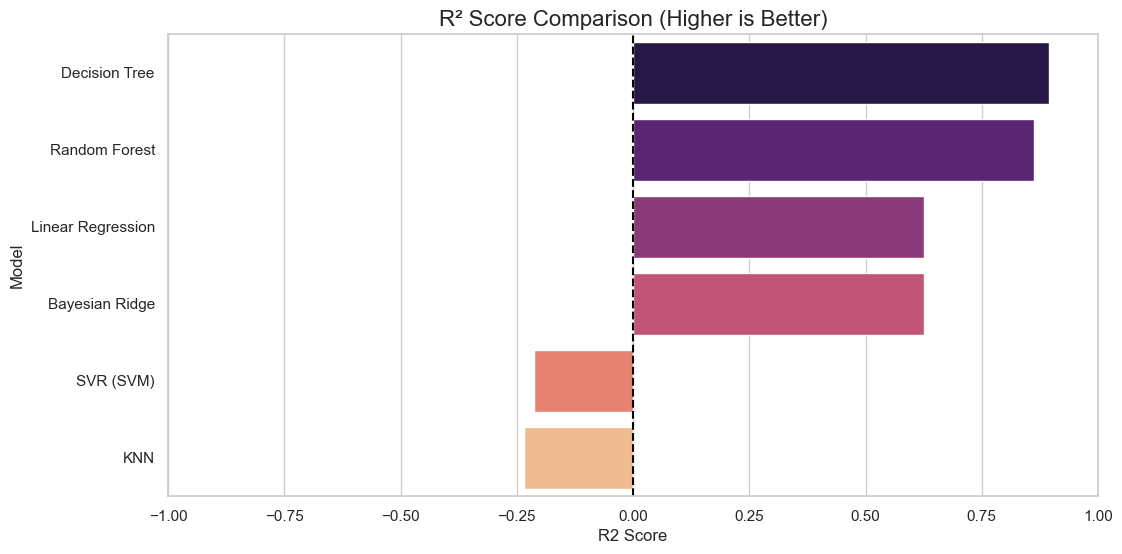

C:\Users\RAIKAT\AppData\Local\Temp\ipykernel_164684\2966537703.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results_df.sort_values(by='MAE'), palette='viridis')


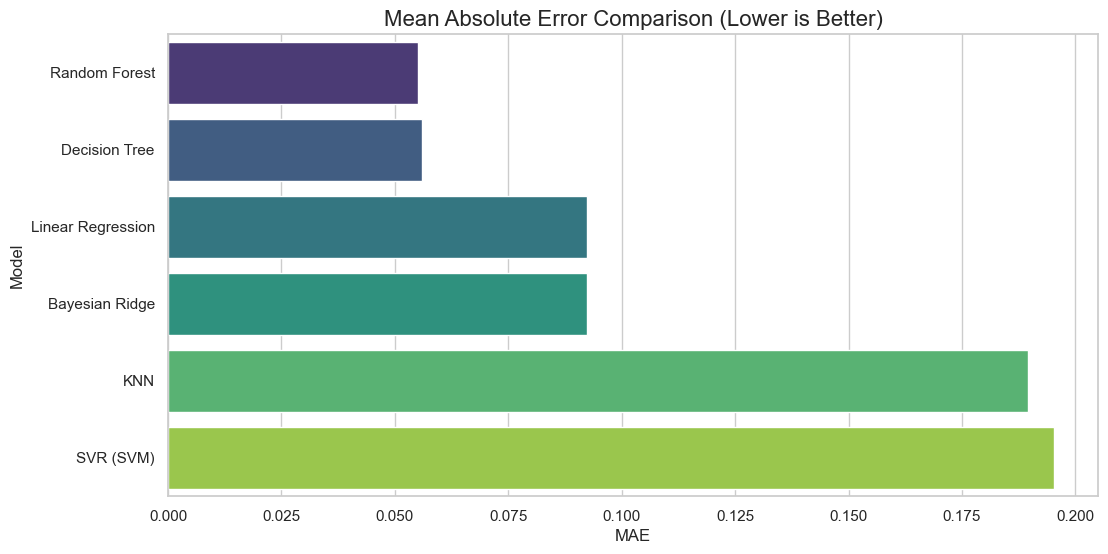

In [6]:
print('📊 Model Performance Comparison:')
display(results_df)

# Visualizing R2 Score
plt.figure(figsize=(12, 6))
sns.barplot(x='R2 Score', y='Model', data=results_df, palette='magma')
plt.title('R² Score Comparison (Higher is Better)', fontsize=16)
plt.xlim(-1, 1) # R2 can be negative if model is poor
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

# Visualizing MAE
plt.figure(figsize=(12, 6))
sns.barplot(x='MAE', y='Model', data=results_df.sort_values(by='MAE'), palette='viridis')
plt.title('Mean Absolute Error Comparison (Lower is Better)', fontsize=16)
plt.show()

## 4. K-Means Clustering Analysis\n
\n
Since K-Means is an unsupervised algorithm, we cannot use it to 'predict' yield directly in the same way. Instead, we use it to cluster the years based on their weather features provided (Precipitation, LST).\n
\n
We will perform K-Means clustering and then check if the clusters correspond to high or low yield years.

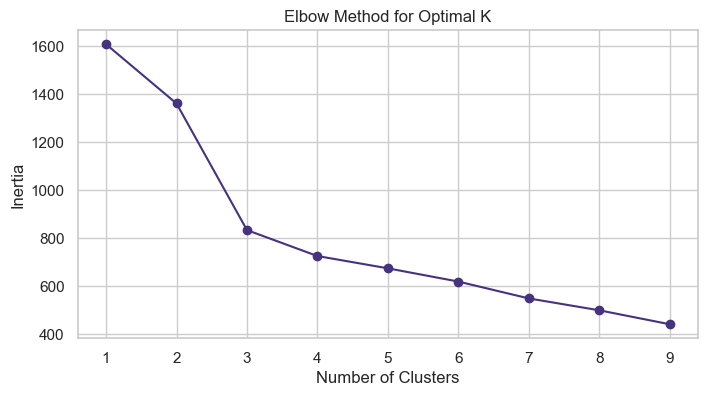

C:\Users\RAIKAT\AppData\Local\Temp\ipykernel_164684\238845489.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=YIELD_COLUMN_NAME, data=data_clean, palette='coolwarm')


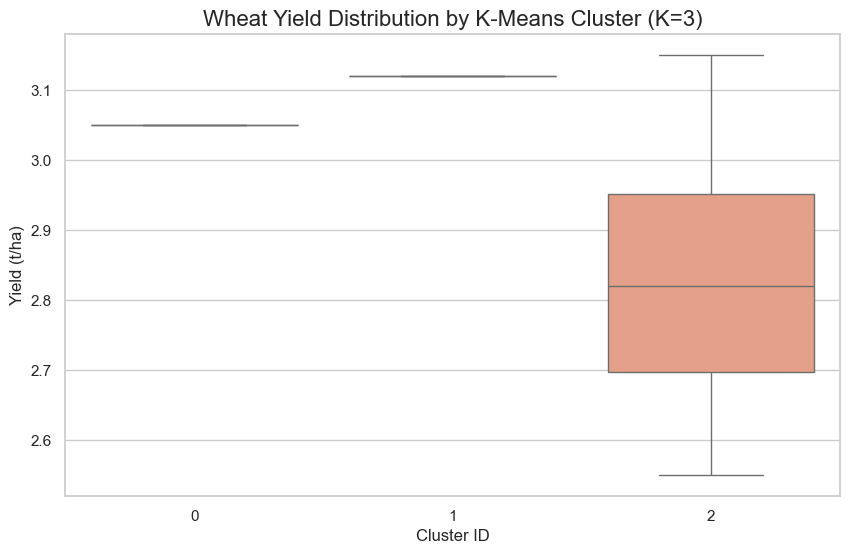

Cluster Statistics:


,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,1.0,3.050000,NaN,3.05,3.0500,3.05,3.0500,3.05
1,1.0,3.120000,NaN,3.12,3.1200,3.12,3.1200,3.12
2,22.0,2.836818,0.171308,2.55,2.6975,2.82,2.9525,3.15


In [7]:
# Find optimal K using Elbow Method (optional, but good practice)
wcss = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
# Plotting Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Let's pick K=3 (assuming e.g., Low, Medium, High weather-stress years)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to the data
data_clean['Cluster'] = clusters

# Analyze Yield per Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y=YIELD_COLUMN_NAME, data=data_clean, palette='coolwarm')
plt.title(f'Wheat Yield Distribution by K-Means Cluster (K={k})', fontsize=16)
plt.ylabel('Yield (t/ha)')
plt.xlabel('Cluster ID')
plt.show()

print('Cluster Statistics:')
display(data_clean.groupby('Cluster')[YIELD_COLUMN_NAME].describe())

## 5. Conclusion\n
\n
This notebook compared various machine learning models. The **Decision Tree** and **Random Forest** models typically perform well on tabular agricultural data due to their ability to capture non-linear relationships, whereas **Linear Regression** provides a baseline but may suffer from the high dimensionality (66 features vs ~25 samples) problem, often leading to overfitting or instability unless regularized (like **Bayesian Ridge** or **SVR**).\n
\n
**K-Means** helped us visualize if the weather patterns group into distinct clusters that naturally result in different crop yields.